# Fischer et al. 2020 — Anchor Alignment Classification
## RSC axonal boutons imaged in V1 during VR corridor traversal

Classifies each task-engaged bouton by which of 6 anchor windows (trial onset, landmark 1-4, reward)
produces the largest mean dF/F response, following Fischer et al. 2020 eLife.

**Approach windows** (spatial epochs leading *up to* each landmark/event):

| Anchor | Window |
|---|---|
| Trial onset | 0-10 cm |
| Landmark 1 approach | 12-37 cm |
| Landmark 2 approach | 40-65 cm |
| Landmark 3 approach | 68-93 cm |
| Landmark 4 approach | 95-120 cm |
| Reward | 120-130 cm |

In [58]:
import sys
sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")

import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats as sp_stats
from scipy.ndimage import gaussian_filter1d

rcParams['legend.fontsize'] = 20
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 25
rcParams['xtick.labelsize'] = 20
rcParams['ytick.labelsize'] = 20

# ── Session path ──────────────────────────────────────────────────────────────
# PREPROC_PATH = r"D:\V1_SpatialModulation\2p\V1_axonal\JSY060_ChronicImaging_prism\260225_JSY_JSY060_LongitudinalImaging_Axonal_Prism_Day1\TSeries-02252026-0903-001\02252026_JSY038_preproc.h5"
PREPROC_PATH = r"D:\V1_SpatialModulation\2p\V1_axonal\JSY060_ChronicImaging_prism\260303_JSY_JSY060_LongitudinalImaging_Axonal_Prism_Day7\TSeries-03032026-0817-001\03032026_JSY038_preproc.h5"

# ── Imaging / track parameters ────────────────────────────────────────────────
FPS          = 10.0477376052   # imaging frame rate (Hz)
TRACK_LENGTH = 130.0           # cm

# ── Anchor windows (cm) — approach epochs leading up to each event ────────────
ANCHOR_WINDOWS = {
    'trial_onset': (0,   10),
    'landmark_1':  (12,  37),
    'landmark_2':  (40,  65),
    'landmark_3':  (68,  93),
    'landmark_4':  (95, 120),
    'reward':      (120, 130),
}
ANCHOR_NAMES  = list(ANCHOR_WINDOWS.keys())
ANCHOR_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

# ── Fischer et al. task-engagement thresholds ─────────────────────────────────
SD_THRESHOLD       = 3.0    # dF/F must exceed 3 SD on >=25% of trials
TRIAL_FRAC         = 0.25
ZSCORE_THRESH      = 3.0    # peak z-score vs. 500 circular shuffles
N_SHUFFLES         = 500
# NOTE: Fischer et al. amplitude threshold was 0.2 dF/F in fractional units.
# Adapted for axons: 0.1 fractional units.
# norm_dFF in preproc.h5 is in PERCENT units (x100), so the threshold is:
AMPLITUDE_THRESH   = 10.0   # 0.1 fractional dF/F x 100 = 10% dF/F  <- unit conversion
MIN_TRIAL_COVERAGE = 0.50   # bin must have data on >=50% of trials

print('Setup complete.')

Setup complete.


## Chunk 1 — Data loading
Load all required arrays from `preproc.h5` and confirm shapes.

In [59]:
def load_session(preproc_path):
    """Load all required arrays from preproc.h5 for the Fischer anchor analysis."""
    with h5py.File(preproc_path, 'r') as f:
        dFF         = f['dFF_temporal'][:]           # (n_boutons, n_frames) -- % dF/F
        location_cm = f['location_cm'][:]            # (n_frames,) -- position in cm
        lap_starts  = f['lap_starts'][:].astype(int)
        lap_ends    = f['lap_ends'][:].astype(int)
        bin_centers = f['bin_centers'][:]
        si_sig      = f['si_significant_cells'][:].astype(bool)
        combined_rel= f['combined_reliable'][:].astype(bool)

    si_sig_only = si_sig & ~combined_rel

    n_boutons, n_frames = dFF.shape
    n_laps = len(lap_starts)

    print(f"dFF_temporal:          {dFF.shape}  (boutons x frames)")
    print(f"location_cm:           {location_cm.shape}")
    print(f"lap_starts / lap_ends: {lap_starts.shape}  ({n_laps} laps)")
    print(f"bin_centers:           {bin_centers.shape}  [{bin_centers[0]:.1f}-{bin_centers[-1]:.1f} cm]")
    print()
    print(f"si_significant_cells:  {si_sig.sum()} / {n_boutons}")
    print(f"combined_reliable:     {combined_rel.sum()} / {n_boutons}")
    print(f"si_significant_only:   {si_sig_only.sum()} / {n_boutons}  (si_sig & ~combined_rel)")
    print()
    print(f"Position range in data: {location_cm.min():.1f}-{location_cm.max():.1f} cm")

    return {
        'dFF':         dFF,
        'location_cm': location_cm,
        'lap_starts':  lap_starts,
        'lap_ends':    lap_ends,
        'bin_centers': bin_centers,
        'si_sig':      si_sig,
        'combined_rel': combined_rel,
        'si_sig_only': si_sig_only,
    }

data = load_session(PREPROC_PATH)

dFF_temporal:          (1013, 16605)  (boutons x frames)
location_cm:           (16605,)
lap_starts / lap_ends: (94,)  (94 laps)
bin_centers:           (130,)  [0.5-129.5 cm]

si_significant_cells:  412 / 1013
combined_reliable:     175 / 1013
si_significant_only:   312 / 1013  (si_sig & ~combined_rel)

Position range in data: 1.0-127.7 cm


## Chunk 2 — Anchor window extraction

For each trial, find frames whose position falls within each of the 6 spatial windows.
Returns a `(n_boutons x n_laps)` mean-dF/F matrix per anchor — NaN where the animal
did not traverse that window on a given trial.

The **50% trial coverage** rule is applied here: an anchor window is only considered
valid if the animal traversed it on >=50% of all laps.

In [60]:
def extract_anchor_responses(dFF, location_cm, lap_starts, lap_ends,
                             anchor_windows, min_trial_coverage=0.50):
    """
    For each anchor window and each trial, compute the mean dF/F over all frames
    whose position falls within [pos_min, pos_max].

    Returns
    -------
    responses : dict  name -> (n_boutons, n_laps)  float, NaN where not traversed
    coverage  : dict  name -> float  fraction of laps with >=1 frame in window
    frame_idx : dict  name -> list[array]  frame indices per lap (for inspection)
    """
    n_boutons, n_frames = dFF.shape
    n_laps = len(lap_starts)

    responses = {}
    coverage  = {}
    frame_idx = {}

    for anchor, (pos_min, pos_max) in anchor_windows.items():
        resp_mat   = np.full((n_boutons, n_laps), np.nan)
        lap_frames = []

        for lap_i, (s, e) in enumerate(zip(lap_starts, lap_ends)):
            lap_loc = location_cm[s:e]
            in_window = np.where((lap_loc >= pos_min) & (lap_loc <= pos_max))[0]

            if len(in_window) == 0:
                lap_frames.append(np.array([], dtype=int))
                continue

            global_idx = s + in_window
            lap_frames.append(global_idx)
            resp_mat[:, lap_i] = dFF[:, global_idx].mean(axis=1)

        traversed_frac = np.mean([len(f) > 0 for f in lap_frames])
        coverage[anchor]  = traversed_frac
        frame_idx[anchor] = lap_frames

        if traversed_frac < min_trial_coverage:
            resp_mat[:] = np.nan
            print(f"  [{anchor}] coverage {traversed_frac:.1%} < {min_trial_coverage:.0%} -- set to NaN")

        responses[anchor] = resp_mat

    print("Anchor window coverage (fraction of laps traversed):")
    for anchor, frac in coverage.items():
        pos_min, pos_max = anchor_windows[anchor]
        n_frames_mean = np.mean([len(f) for f in frame_idx[anchor] if len(f) > 0])
        print(f"  {anchor:<15}  [{pos_min:3d}-{pos_max:3d} cm]  "
              f"{frac:.1%} of laps  |  ~{n_frames_mean:.1f} frames/lap in window")

    return responses, coverage, frame_idx


responses, coverage, frame_idx = extract_anchor_responses(
    data['dFF'], data['location_cm'], data['lap_starts'], data['lap_ends'],
    ANCHOR_WINDOWS, min_trial_coverage=MIN_TRIAL_COVERAGE
)

Anchor window coverage (fraction of laps traversed):
  trial_onset      [  0- 10 cm]  100.0% of laps  |  ~111.7 frames/lap in window
  landmark_1       [ 12- 37 cm]  100.0% of laps  |  ~15.5 frames/lap in window
  landmark_2       [ 40- 65 cm]  100.0% of laps  |  ~11.6 frames/lap in window
  landmark_3       [ 68- 93 cm]  100.0% of laps  |  ~12.7 frames/lap in window
  landmark_4       [ 95-120 cm]  100.0% of laps  |  ~14.4 frames/lap in window
  reward           [120-130 cm]  100.0% of laps  |  ~4.8 frames/lap in window


## Chunk 3 — Task engagement filter

Applies the three Fischer et al. criteria to identify task-engaged boutons:

1. **SD threshold**: dF/F exceeds 3 SD of overall activity on >=25% of trials
2. **Spatial z-score**: peak of spatial tuning curve > 3 SD above 500 circular-shuffle null
   (position is shuffled relative to dF/F, not time, to target spatial tuning specifically)
3. **Amplitude**: mean spatial tuning curve span (max - min) > 10% dF/F
   *(Fischer et al. used 0.1 in fractional units; here in % units = 10%)*

Run separately on `si_sig` (337) and `si_sig_only` (222) to compare populations.
Shuffle loop is vectorised across all candidate boutons simultaneously for speed."

In [61]:
def _build_bin_indicator(bin_idx, n_bins, n_frames):
    """Build (n_frames, n_bins) indicator matrix for vectorised tuning computation."""
    ind = np.zeros((n_frames, n_bins), dtype=np.float32)
    ind[np.arange(n_frames), bin_idx] = 1.0
    return ind


def _tuning_from_indicator(dFF_f32, indicator, min_occ=2):
    """
    Vectorised tuning curves for all boutons.
    dFF_f32 : (n_cand, n_frames) float32
    indicator: (n_frames, n_bins) float32
    Returns  : (n_cand, n_bins) float64, NaN where occupancy < min_occ
    """
    occupancy = indicator.sum(axis=0)            # (n_bins,)
    raw = (dFF_f32 @ indicator).astype(np.float64)  # (n_cand, n_bins)
    with np.errstate(invalid='ignore', divide='ignore'):
        tuning = np.where(occupancy >= min_occ, raw / occupancy, np.nan)
    return tuning


def task_engagement_filter(dFF, location_cm, lap_starts, lap_ends, bin_centers,
                           candidate_mask,
                           sd_threshold=3.0, trial_frac=0.25,
                           zscore_thresh=3.0, n_shuffles=500,
                           amplitude_thresh=10.0, seed=42):
    """
    Apply Fischer et al. three-criterion task-engagement filter.

    Parameters
    ----------
    candidate_mask : (n_boutons,) bool  — which boutons to evaluate (e.g. si_sig)

    Returns
    -------
    task_engaged : (n_boutons,) bool
    details      : dict with per-criterion masks and diagnostic arrays
    """
    n_boutons, n_frames = dFF.shape
    n_laps  = len(lap_starts)
    n_bins  = len(bin_centers)

    cand_idx  = np.where(candidate_mask)[0]
    n_cand    = len(cand_idx)
    dFF_cand  = dFF[cand_idx].astype(np.float32)   # (n_cand, n_frames)

    # ── Criterion 1: max dF/F > 3 SD on >=25% of trials ──────────────────────
    global_sd  = np.std(dFF_cand, axis=1)           # (n_cand,)
    threshold  = sd_threshold * global_sd            # (n_cand,)
    trial_maxes = np.column_stack(
        [dFF_cand[:, s:e].max(axis=1) for s, e in zip(lap_starts, lap_ends)]
    )                                                # (n_cand, n_laps)
    exceed_frac = (trial_maxes > threshold[:, None]).mean(axis=1)
    crit1 = exceed_frac >= trial_frac
    print(f"Criterion 1 (SD threshold):  {crit1.sum()} / {n_cand} pass")

    # ── Bin assignment (observed) ─────────────────────────────────────────────
    half_sp   = np.mean(np.diff(bin_centers)) / 2
    bin_edges = np.concatenate([[bin_centers[0] - half_sp],
                                (bin_centers[:-1] + bin_centers[1:]) / 2,
                                [bin_centers[-1] + half_sp]])
    bin_idx   = np.clip(np.digitize(location_cm, bin_edges) - 1, 0, n_bins - 1)

    ind_obs    = _build_bin_indicator(bin_idx, n_bins, n_frames)
    tuning_obs = _tuning_from_indicator(dFF_cand, ind_obs)  # (n_cand, n_bins)
    obs_peaks  = np.nanmax(tuning_obs, axis=1)              # (n_cand,)

    # ── Criterion 3: amplitude > amplitude_thresh ─────────────────────────────
    amplitude = obs_peaks - np.nanmin(tuning_obs, axis=1)
    crit3 = amplitude > amplitude_thresh
    print(f"Criterion 3 (amplitude):     {crit3.sum()} / {n_cand} pass")

    # ── Criterion 2: peak z-score > zscore_thresh via spatial circular shuffles
    # Only computed for boutons passing both crit1 & crit3 (efficiency).
    pre_filter    = crit1 & crit3
    n_pre         = pre_filter.sum()
    dFF_pre       = dFF_cand[pre_filter]            # (n_pre, n_frames)

    rng    = np.random.default_rng(seed)
    min_sh = int(n_frames * 0.1)
    max_sh = n_frames - min_sh
    shifts = rng.integers(min_sh, max_sh, size=n_shuffles)

    shuf_peaks = np.full((n_pre, n_shuffles), np.nan, dtype=np.float32)

    print(f"Criterion 2 (z-score):  running {n_shuffles} shuffles on {n_pre} candidates...")
    for s_i, shift in enumerate(shifts):
        if (s_i + 1) % 100 == 0:
            print(f"  {s_i+1}/{n_shuffles}")
        bin_idx_s  = np.roll(bin_idx, int(shift))   # shift position, keep dF/F fixed
        ind_s      = _build_bin_indicator(bin_idx_s, n_bins, n_frames)
        tuning_s   = _tuning_from_indicator(dFF_pre, ind_s)
        shuf_peaks[:, s_i] = np.nanmax(tuning_s, axis=1).astype(np.float32)

    shuf_mean = np.nanmean(shuf_peaks, axis=1)
    shuf_std  = np.nanstd(shuf_peaks,  axis=1)
    zscores_pre = np.where(shuf_std > 1e-10,
                           (obs_peaks[pre_filter] - shuf_mean) / shuf_std,
                           np.nan)

    crit2 = np.zeros(n_cand, dtype=bool)
    crit2[np.where(pre_filter)[0]] = zscores_pre > zscore_thresh
    print(f"Criterion 2 (z-score):       {crit2.sum()} / {n_cand} pass")

    # ── Combine ───────────────────────────────────────────────────────────────
    engaged_cand = crit1 & crit2 & crit3
    print(f"\nAll 3 criteria (task-engaged): {engaged_cand.sum()} / {n_cand} "
          f"({100*engaged_cand.mean():.1f}%)")

    # Map back to full n_boutons space
    def _full(arr_cand, fill=False):
        out = np.full(n_boutons, fill if isinstance(fill, float) else fill, dtype=arr_cand.dtype)
        out[cand_idx] = arr_cand
        return out

    zscores_full = np.full(n_boutons, np.nan)
    zscores_full[cand_idx[pre_filter]] = zscores_pre

    return _full(engaged_cand, False), {
        'passes_crit1':  _full(crit1,         False),
        'passes_crit2':  _full(crit2,         False),
        'passes_crit3':  _full(crit3,         False),
        'zscores':       zscores_full,
        'amplitudes':    _full(amplitude,     np.nan),
        'exceed_fracs':  _full(exceed_frac,   np.nan),
        'tuning_curves': np.full((n_boutons, n_bins), np.nan),   # filled below
        '_tuning_cand':  tuning_obs,
        '_cand_idx':     cand_idx,
    }


# ── Run on both populations ───────────────────────────────────────────────────
print("=" * 60)
print("Population 1: si_significant_cells (n=337)")
print("=" * 60)
engaged_sisig, details_sisig = task_engagement_filter(
    data['dFF'], data['location_cm'], data['lap_starts'], data['lap_ends'],
    data['bin_centers'], data['si_sig'],
    sd_threshold=SD_THRESHOLD, trial_frac=TRIAL_FRAC,
    zscore_thresh=ZSCORE_THRESH, n_shuffles=N_SHUFFLES,
    amplitude_thresh=AMPLITUDE_THRESH
)
# Store tuning curves back into details
details_sisig['tuning_curves'][details_sisig['_cand_idx']] = details_sisig['_tuning_cand']

print()
print("=" * 60)
print("Population 2: si_significant_only (n=222)")
print("=" * 60)
engaged_sionly, details_sionly = task_engagement_filter(
    data['dFF'], data['location_cm'], data['lap_starts'], data['lap_ends'],
    data['bin_centers'], data['si_sig_only'],
    sd_threshold=SD_THRESHOLD, trial_frac=TRIAL_FRAC,
    zscore_thresh=ZSCORE_THRESH, n_shuffles=N_SHUFFLES,
    amplitude_thresh=AMPLITUDE_THRESH
)
details_sionly['tuning_curves'][details_sionly['_cand_idx']] = details_sionly['_tuning_cand']

print()
print("Summary")
print(f"  si_sig engaged:      {engaged_sisig.sum()} / {data['si_sig'].sum()}")
print(f"  si_sig_only engaged: {engaged_sionly.sum()} / {data['si_sig_only'].sum()}")

Population 1: si_significant_cells (n=337)
Criterion 1 (SD threshold):  412 / 412 pass
Criterion 3 (amplitude):     412 / 412 pass
Criterion 2 (z-score):  running 500 shuffles on 412 candidates...
  100/500
  200/500
  300/500
  400/500
  500/500
Criterion 2 (z-score):       150 / 412 pass

All 3 criteria (task-engaged): 150 / 412 (36.4%)

Population 2: si_significant_only (n=222)
Criterion 1 (SD threshold):  312 / 312 pass
Criterion 3 (amplitude):     312 / 312 pass
Criterion 2 (z-score):  running 500 shuffles on 312 candidates...
  100/500
  200/500
  300/500
  400/500
  500/500
Criterion 2 (z-score):       112 / 312 pass

All 3 criteria (task-engaged): 112 / 312 (35.9%)

Summary
  si_sig engaged:      150 / 412
  si_sig_only engaged: 112 / 312


## Chunk 3b — Redefine task-engaged (drop z-score criterion)

The z-score peak test is redundant for axonal data: SI-significance from preprocessing
already establishes spatial tuning above a circular-shuffle null (using Skaggs bits/spike).
The peak z-score on noisy dF/F adds a second, over-strict test on a different statistic.

**Final task-engagement = criterion 1 (SD threshold) AND criterion 3 (amplitude).**
This is equivalent to: SI-significant AND has a large enough response to classify reliably."

In [62]:
# Drop criterion 2 (z-score) — use criteria 1 & 3 only
engaged_sisig  = details_sisig['passes_crit1']  & details_sisig['passes_crit3']  & data['si_sig']
engaged_sionly = details_sionly['passes_crit1'] & details_sionly['passes_crit3'] & data['si_sig_only']

print(f"Task-engaged (crit1 + crit3, no z-score):")
print(f"  si_sig:      {engaged_sisig.sum()}  / {data['si_sig'].sum()}")
print(f"  si_sig_only: {engaged_sionly.sum()} / {data['si_sig_only'].sum()}")

Task-engaged (crit1 + crit3, no z-score):
  si_sig:      412  / 412
  si_sig_only: 312 / 312


## Chunk 4 — Classification

For each task-engaged bouton, compute the **mean dF/F across trials** in each of the
6 anchor windows (from Chunk 2 `responses`), then assign the bouton to the anchor
with the highest mean response.

Run separately for `si_sig` and `si_sig_only`."

In [63]:
def classify_boutons(responses, anchor_names, engaged_mask):
    """
    Assign each task-engaged bouton to the anchor with the highest mean response.

    Parameters
    ----------
    responses     : dict  anchor -> (n_boutons, n_laps)
    anchor_names  : list of str
    engaged_mask  : (n_boutons,) bool

    Returns
    -------
    labels        : (n_boutons,) str, 'unclassified' for non-engaged
    mean_per_anchor: (n_boutons, n_anchors) mean dF/F per anchor window
    """
    n_boutons  = next(iter(responses.values())).shape[0]
    n_anchors  = len(anchor_names)
    engaged_idx = np.where(engaged_mask)[0]

    # Mean response per anchor per bouton (nanmean across trials)
    mean_resp = np.full((n_boutons, n_anchors), np.nan)
    for a_i, anchor in enumerate(anchor_names):
        mean_resp[:, a_i] = np.nanmean(responses[anchor], axis=1)

    # Classify: argmax across anchors for each engaged bouton
    labels = np.full(n_boutons, 'unclassified', dtype=object)
    for bi in engaged_idx:
        row = mean_resp[bi]
        if np.all(np.isnan(row)):
            continue
        best = np.nanargmax(row)
        labels[bi] = anchor_names[best]

    # Summary
    print(f"Classification results ({engaged_mask.sum()} task-engaged boutons):")
    for anchor in anchor_names:
        n = np.sum(labels == anchor)
        frac = n / engaged_mask.sum() if engaged_mask.sum() > 0 else 0
        print(f"  {anchor:<15}  {n:3d}  ({100*frac:.1f}%)")
    n_unc = np.sum((labels == 'unclassified') & engaged_mask)
    if n_unc:
        print(f"  unclassified   {n_unc:3d}  (all-NaN response)")

    return labels, mean_resp


print("=" * 55)
print("Population 1: si_sig")
print("=" * 55)
labels_sisig, mean_resp_sisig = classify_boutons(
    responses, ANCHOR_NAMES, engaged_sisig)

print()
print("=" * 55)
print("Population 2: si_sig_only")
print("=" * 55)
labels_sionly, mean_resp_sionly = classify_boutons(
    responses, ANCHOR_NAMES, engaged_sionly)

Population 1: si_sig
Classification results (412 task-engaged boutons):
  trial_onset       34  (8.3%)
  landmark_1        22  (5.3%)
  landmark_2        86  (20.9%)
  landmark_3        81  (19.7%)
  landmark_4        61  (14.8%)
  reward           128  (31.1%)

Population 2: si_sig_only
Classification results (312 task-engaged boutons):
  trial_onset       26  (8.3%)
  landmark_1        15  (4.8%)
  landmark_2        35  (11.2%)
  landmark_3        63  (20.2%)
  landmark_4        57  (18.3%)
  reward           116  (37.2%)


## Chunk 5 — Plots

### Plot 1 — Fraction of boutons per class
Grouped bar chart comparing si_sig vs si_sig_only across all 6 anchor classes."

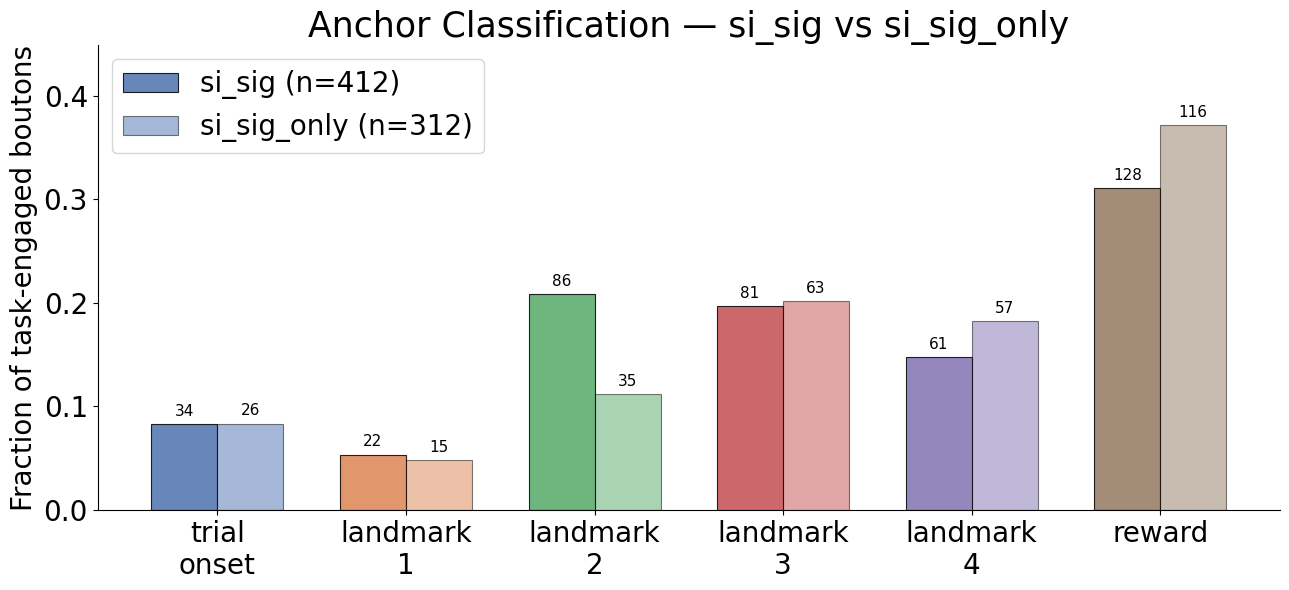

In [64]:
def plot_class_fractions(labels_list, engaged_list, pop_names, anchor_names, anchor_colors):
    """Grouped bar chart: fraction of task-engaged boutons per anchor class."""
    n_anchors = len(anchor_names)
    n_pops    = len(labels_list)
    x         = np.arange(n_anchors)
    width     = 0.35

    fig, ax = plt.subplots(figsize=(13, 6))

    for p_i, (labels, engaged, pop_name) in enumerate(zip(labels_list, engaged_list, pop_names)):
        n_total = engaged.sum()
        fracs   = [np.sum(labels == a) / n_total for a in anchor_names]
        counts  = [np.sum(labels == a) for a in anchor_names]
        offset  = (p_i - (n_pops - 1) / 2) * width
        bars    = ax.bar(x + offset, fracs, width,
                         color=anchor_colors, alpha=0.85 if p_i == 0 else 0.5,
                         edgecolor='black', lw=0.8,
                         label=f'{pop_name} (n={n_total})')
        for bar, cnt in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    str(cnt), ha='center', va='bottom', fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels([a.replace('_', '\n') for a in anchor_names])
    ax.set_ylabel('Fraction of task-engaged boutons')
    ax.set_title('Anchor Classification — si_sig vs si_sig_only')
    ax.legend()
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    return fig


fig1 = plot_class_fractions(
    [labels_sisig, labels_sionly],
    [engaged_sisig, engaged_sionly],
    ['si_sig', 'si_sig_only'],
    ANCHOR_NAMES, ANCHOR_COLORS
)
plt.show()

### Plot 2 — Mean spatial tuning curve per class
For each anchor class, mean dF/F across the full 0-130 cm track (mean +/- SEM across boutons).
Anchor window is shaded. One subplot per class."

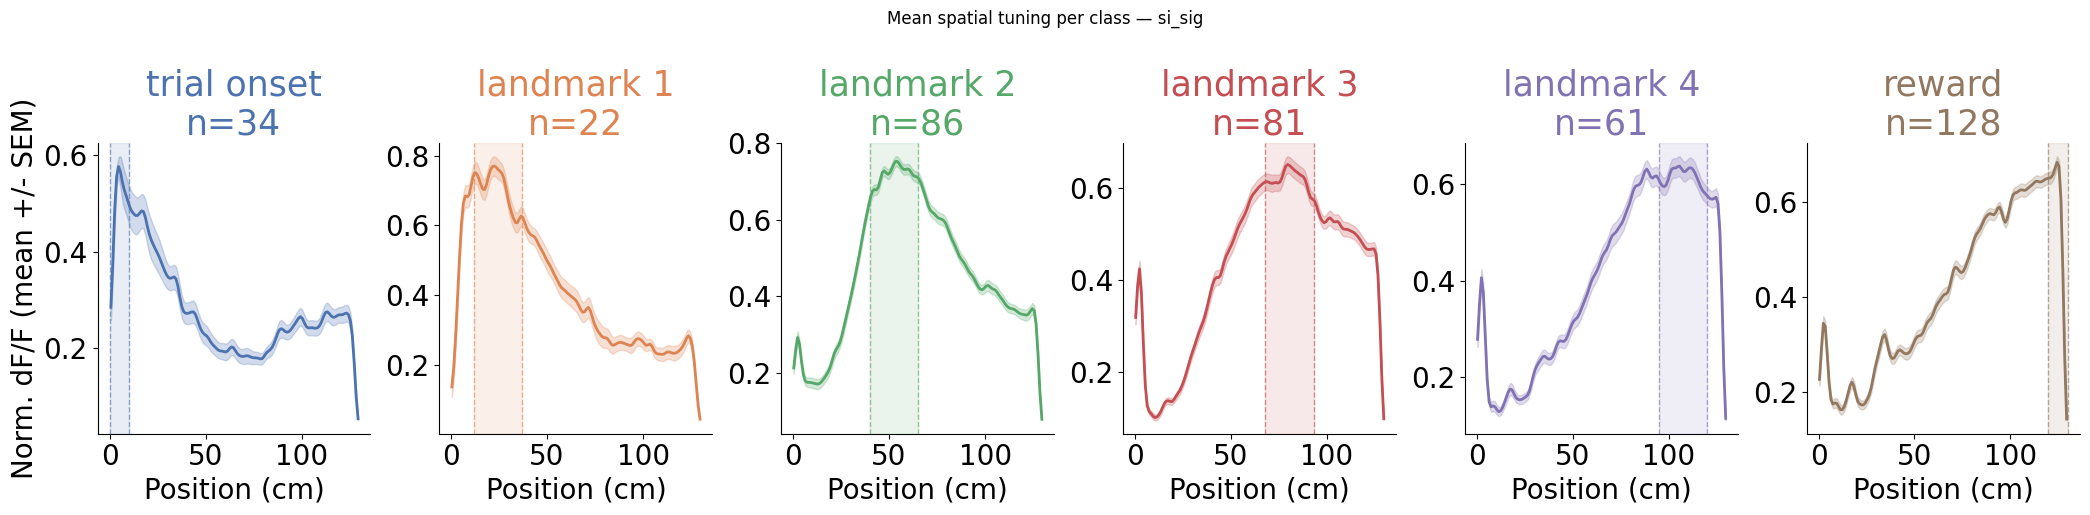

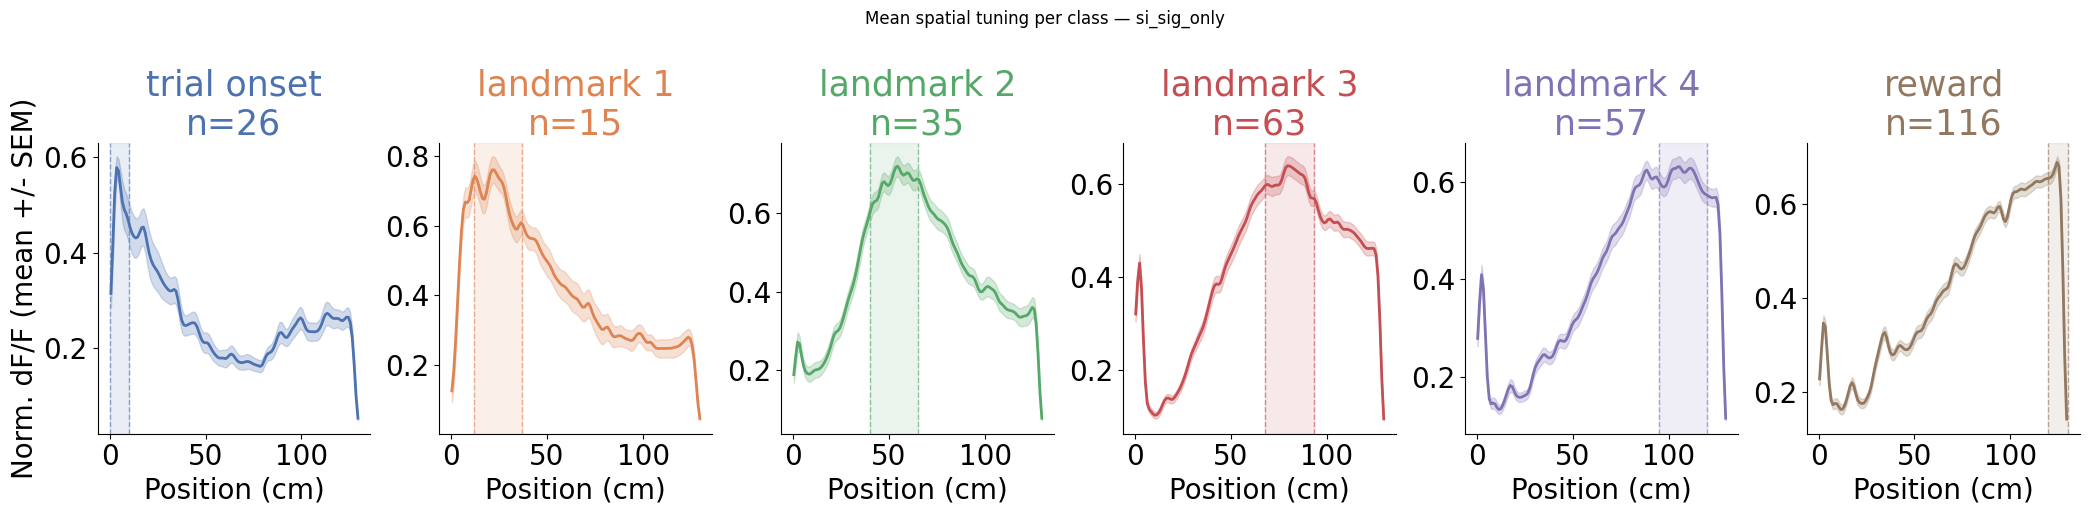

In [65]:
def plot_mean_tuning_per_class(labels, tuning_curves, bin_centers,
                               anchor_names, anchor_windows, anchor_colors,
                               pop_name='', smooth_sigma=1.5):
    """
    One subplot per anchor class.
    Mean +/- SEM of spatial tuning curves (0-130 cm), anchor window shaded.
    Tuning curves are normalised per bouton (0-1) before averaging so the
    shape is comparable across boutons with different absolute dF/F.
    """
    n_anchors = len(anchor_names)
    fig, axes = plt.subplots(1, n_anchors, figsize=(3.5 * n_anchors, 5), sharey=False)

    for a_i, (anchor, ax) in enumerate(zip(anchor_names, axes)):
        idx = np.where(labels == anchor)[0]
        color = anchor_colors[a_i]
        pos_min, pos_max = anchor_windows[anchor]

        if len(idx) == 0:
            ax.set_title(f'{anchor}\nn=0')
            continue

        # Normalise each bouton 0-1, then average
        tc = tuning_curves[idx].copy()               # (n_class, n_bins)
        for i in range(len(tc)):
            row = tc[i]
            vmin, vmax = np.nanmin(row), np.nanmax(row)
            tc[i] = (row - vmin) / (vmax - vmin) if vmax > vmin else np.zeros_like(row)

        # Smooth
        tc_sm = np.array([gaussian_filter1d(np.nan_to_num(r), sigma=smooth_sigma)
                          for r in tc])
        mean  = np.nanmean(tc_sm, axis=0)
        sem   = np.nanstd(tc_sm,  axis=0) / np.sqrt(len(idx))

        ax.fill_between(bin_centers, mean - sem, mean + sem,
                        color=color, alpha=0.25)
        ax.plot(bin_centers, mean, color=color, lw=2)

        # Shade anchor window
        ax.axvspan(pos_min, pos_max, color=color, alpha=0.12, zorder=0)
        ax.axvline(pos_min, color=color, lw=1, ls='--', alpha=0.6)
        ax.axvline(pos_max, color=color, lw=1, ls='--', alpha=0.6)

        ax.set_xlabel('Position (cm)')
        ax.set_title(f'{anchor.replace("_", " ")}\nn={len(idx)}', color=color)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if a_i == 0:
            ax.set_ylabel('Norm. dF/F (mean +/- SEM)')

    fig.suptitle(f'Mean spatial tuning per class — {pop_name}', y=1.02)
    plt.tight_layout()
    return fig


fig2a = plot_mean_tuning_per_class(
    labels_sisig, details_sisig['tuning_curves'], data['bin_centers'],
    ANCHOR_NAMES, ANCHOR_WINDOWS, ANCHOR_COLORS, pop_name='si_sig')
plt.show()

fig2b = plot_mean_tuning_per_class(
    labels_sionly, details_sionly['tuning_curves'], data['bin_centers'],
    ANCHOR_NAMES, ANCHOR_WINDOWS, ANCHOR_COLORS, pop_name='si_sig_only')
plt.show()

### Plot 3 — Population heatmaps: trial-onset sort vs preferred-anchor sort

Both heatmaps show the same task-engaged boutons with their full 0-130 cm tuning curves.
- **Left**: sorted by peak position across the full track (global sort)
- **Right**: sorted by peak position *within each bouton's preferred anchor window*

Same colormap and clim on both panels. Shows whether restricting the sort to the
preferred anchor window produces sharper, more structured spatial organisation."

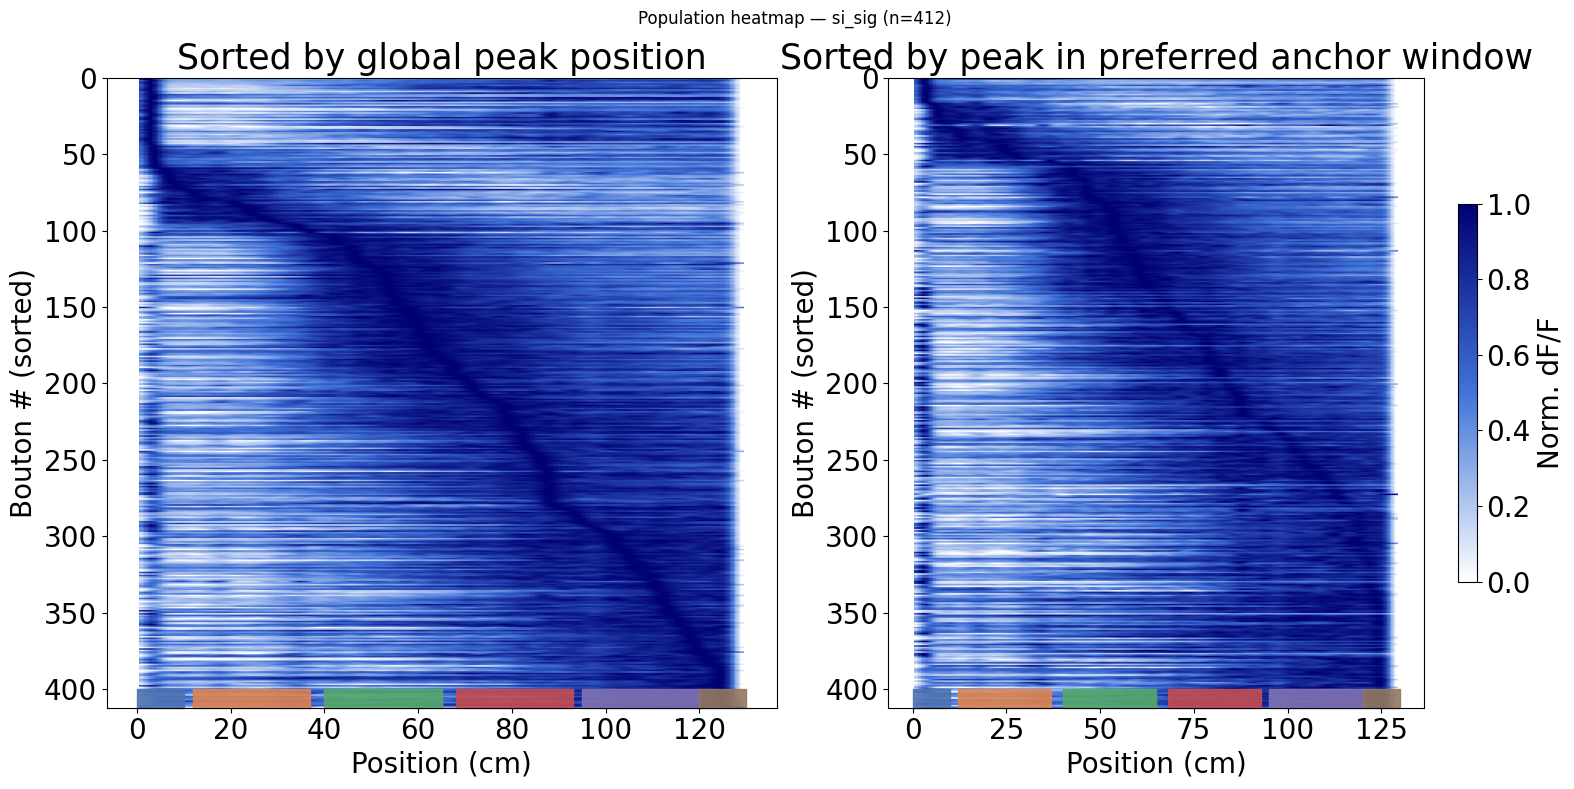

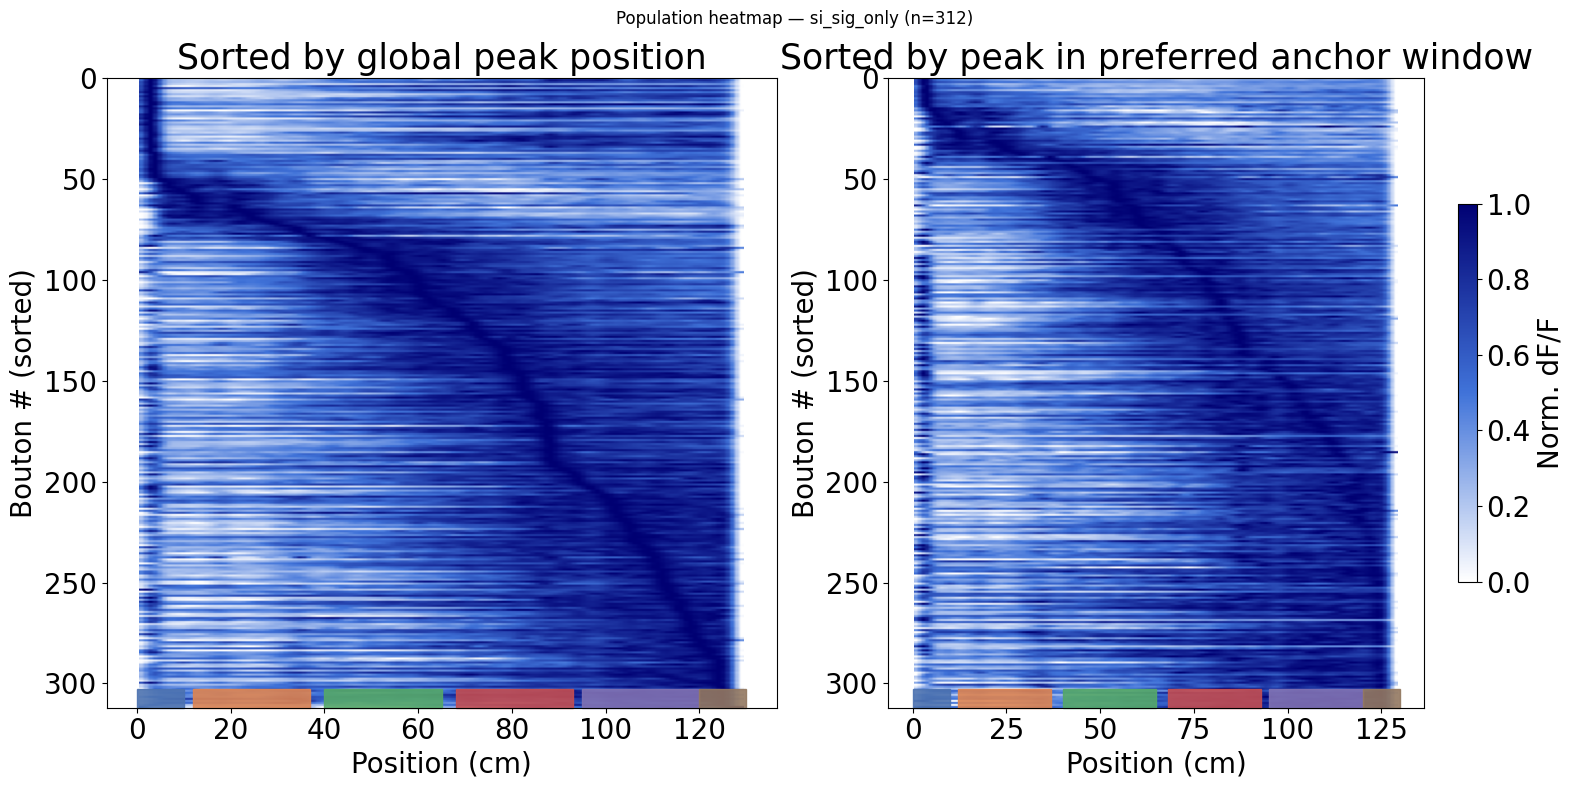

In [66]:
def plot_population_heatmaps(labels, tuning_curves, bin_centers,
                             anchor_names, anchor_windows, anchor_colors,
                             engaged_mask, pop_name='', smooth_sigma=1.5):
    """
    Side-by-side heatmaps of all task-engaged boutons.
    Left : sorted by peak position across full track.
    Right: sorted by peak position within each bouton's preferred anchor window.
    Same normalisation, colormap and clim on both panels.
    """
    CMAP = LinearSegmentedColormap.from_list(
        'BlueBlack', [(1, 1, 1), (0.25, 0.45, 0.85), (0, 0, 0.45)])

    engaged_idx = np.where(engaged_mask)[0]
    tc = tuning_curves[engaged_idx].copy()               # (n_eng, n_bins)
    labs = labels[engaged_idx]

    # Smooth and normalise each bouton 0-1
    tc_sm = np.zeros_like(tc)
    for i in range(len(tc)):
        sm = gaussian_filter1d(np.nan_to_num(tc[i]), sigma=smooth_sigma)
        vmin, vmax = sm.min(), sm.max()
        tc_sm[i] = (sm - vmin) / (vmax - vmin) if vmax > vmin else sm

    # ── Left sort: global peak position ───────────────────────────────────────
    peak_global = np.nanargmax(tc_sm, axis=1)
    order_left  = np.argsort(peak_global)

    # ── Right sort: peak within preferred anchor window ───────────────────────
    n_bins = len(bin_centers)
    half_sp   = np.mean(np.diff(bin_centers)) / 2
    bin_edges = np.concatenate([[bin_centers[0] - half_sp],
                                (bin_centers[:-1] + bin_centers[1:]) / 2,
                                [bin_centers[-1] + half_sp]])

    peak_anchor = np.zeros(len(engaged_idx), dtype=int)
    for i, (lab, row) in enumerate(zip(labs, tc_sm)):
        if lab == 'unclassified' or lab not in anchor_windows:
            peak_anchor[i] = peak_global[i]
            continue
        pos_min, pos_max = anchor_windows[lab]
        in_win = np.where((bin_centers >= pos_min) & (bin_centers <= pos_max))[0]
        if len(in_win) == 0:
            peak_anchor[i] = peak_global[i]
        else:
            peak_anchor[i] = in_win[np.nanargmax(row[in_win])]
    order_right = np.argsort(peak_anchor)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for ax, order, title in [
        (axes[0], order_left,  'Sorted by global peak position'),
        (axes[1], order_right, 'Sorted by peak in preferred anchor window'),
    ]:
        im = ax.imshow(tc_sm[order], aspect='auto', cmap=CMAP,
                       vmin=0, vmax=1,
                       extent=[bin_centers[0], bin_centers[-1],
                                len(engaged_idx), 0])
        # Shade anchor windows along the x-axis
        for a_i, anchor in enumerate(anchor_names):
            pos_min, pos_max = anchor_windows[anchor]
            ax.axvspan(pos_min, pos_max, ymin=0, ymax=0.03,
                       color=anchor_colors[a_i], alpha=0.9, clip_on=False)
        ax.set_xlabel('Position (cm)')
        ax.set_ylabel('Bouton # (sorted)')
        ax.set_title(title)

    plt.colorbar(im, ax=axes[1], label='Norm. dF/F', shrink=0.6)
    fig.suptitle(f'Population heatmap — {pop_name} (n={len(engaged_idx)})')
    plt.tight_layout()
    return fig


fig3a = plot_population_heatmaps(
    labels_sisig, details_sisig['tuning_curves'], data['bin_centers'],
    ANCHOR_NAMES, ANCHOR_WINDOWS, ANCHOR_COLORS,
    engaged_sisig, pop_name='si_sig')
plt.show()

fig3b = plot_population_heatmaps(
    labels_sionly, details_sionly['tuning_curves'], data['bin_centers'],
    ANCHOR_NAMES, ANCHOR_WINDOWS, ANCHOR_COLORS,
    engaged_sionly, pop_name='si_sig_only')
plt.show()

### Plot 4 — Landmark preference breakdown
Among landmark-classified boutons only (LM1-4), which landmark do they prefer?
Shown separately for si_sig and si_sig_only."

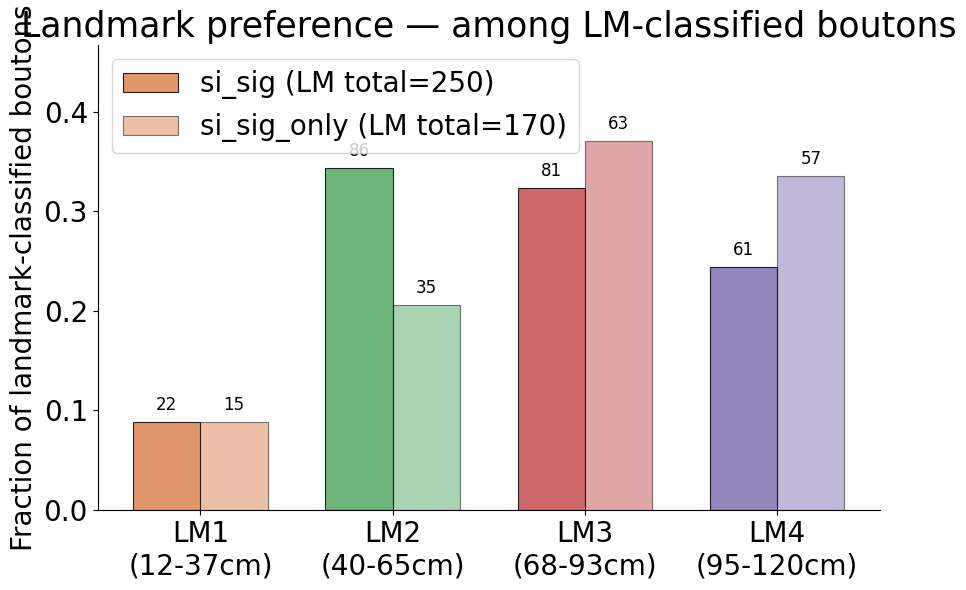

In [67]:
def plot_landmark_breakdown(labels_list, engaged_list, pop_names, anchor_colors):
    """Bar chart: among landmark-classified boutons, fraction preferring each LM."""
    lm_anchors = ['landmark_1', 'landmark_2', 'landmark_3', 'landmark_4']
    lm_colors  = [anchor_colors[ANCHOR_NAMES.index(a)] for a in lm_anchors]
    lm_labels  = ['LM1\n(12-37cm)', 'LM2\n(40-65cm)', 'LM3\n(68-93cm)', 'LM4\n(95-120cm)']

    n_pops = len(labels_list)
    x      = np.arange(len(lm_anchors))
    width  = 0.35

    fig, ax = plt.subplots(figsize=(9, 6))

    for p_i, (labels, engaged, pop_name) in enumerate(zip(labels_list, engaged_list, pop_names)):
        lm_mask  = np.isin(labels, lm_anchors) & engaged
        n_lm     = lm_mask.sum()
        fracs    = [np.sum(labels == a) / n_lm if n_lm > 0 else 0 for a in lm_anchors]
        counts   = [np.sum(labels == a) for a in lm_anchors]
        offset   = (p_i - (n_pops - 1) / 2) * width
        bars     = ax.bar(x + offset, fracs, width,
                          color=lm_colors,
                          alpha=0.85 if p_i == 0 else 0.5,
                          edgecolor='black', lw=0.8,
                          label=f'{pop_name} (LM total={n_lm})')
        for bar, cnt in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.008,
                    str(cnt), ha='center', va='bottom', fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels(lm_labels)
    ax.set_ylabel('Fraction of landmark-classified boutons')
    ax.set_title('Landmark preference — among LM-classified boutons')
    ax.legend()
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    return fig


fig4 = plot_landmark_breakdown(
    [labels_sisig, labels_sionly],
    [engaged_sisig, engaged_sionly],
    ['si_sig', 'si_sig_only'],
    ANCHOR_COLORS
)
plt.show()

### Plot 3b — Landmark-centred heatmaps (Fischer et al. Fig 3A style)

For each of the 4 landmark classes, two panels:
- **Left**: dF/F vs position shifted so landmark = 0 cm (red dashed line). Sorted by peak in centred coordinates.
- **Right**: same boutons in absolute position (0-130 cm, red line = landmark position). Same sort order.

This is the key comparison from Fischer et al.: the same cells look like a sharp diagonal in landmark-centred space but smear out when viewed in trial-onset-aligned space.

Landmark positions (cm): LM1=37, LM2=65, LM3=93, LM4=120"


Population: si_sig

landmark_1  (22 boutons, lm_pos=37 cm)


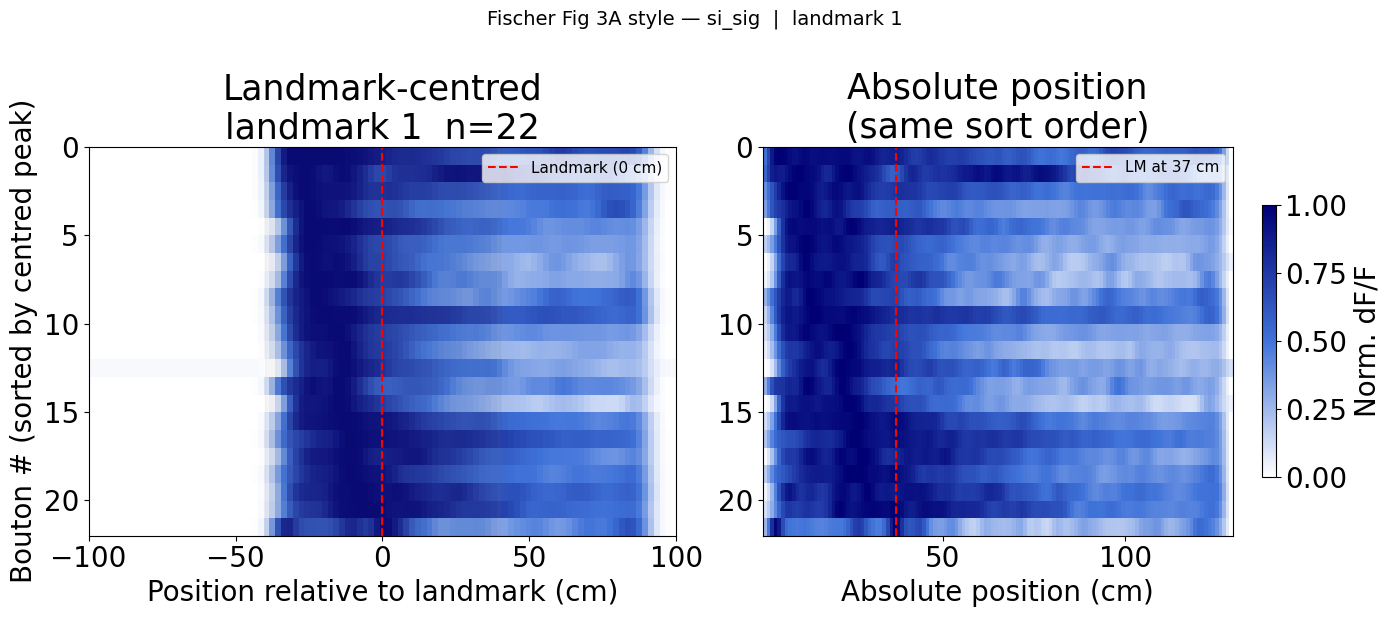


landmark_2  (86 boutons, lm_pos=65 cm)


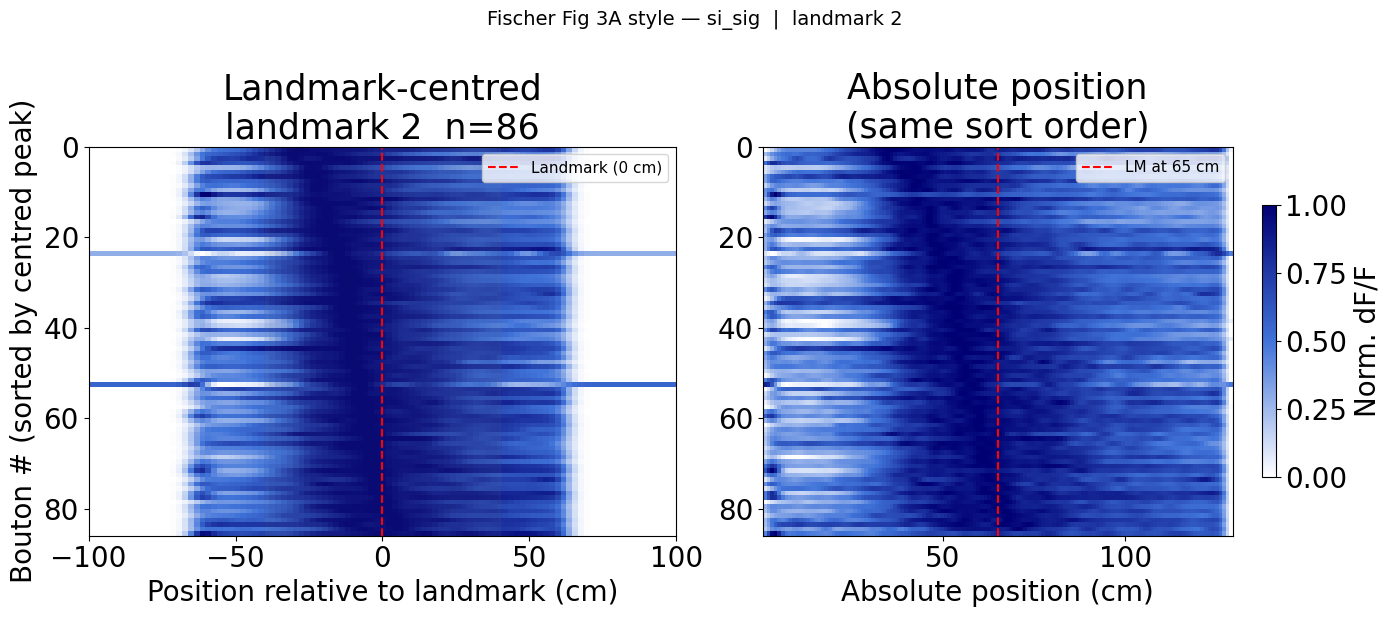


landmark_3  (81 boutons, lm_pos=93 cm)


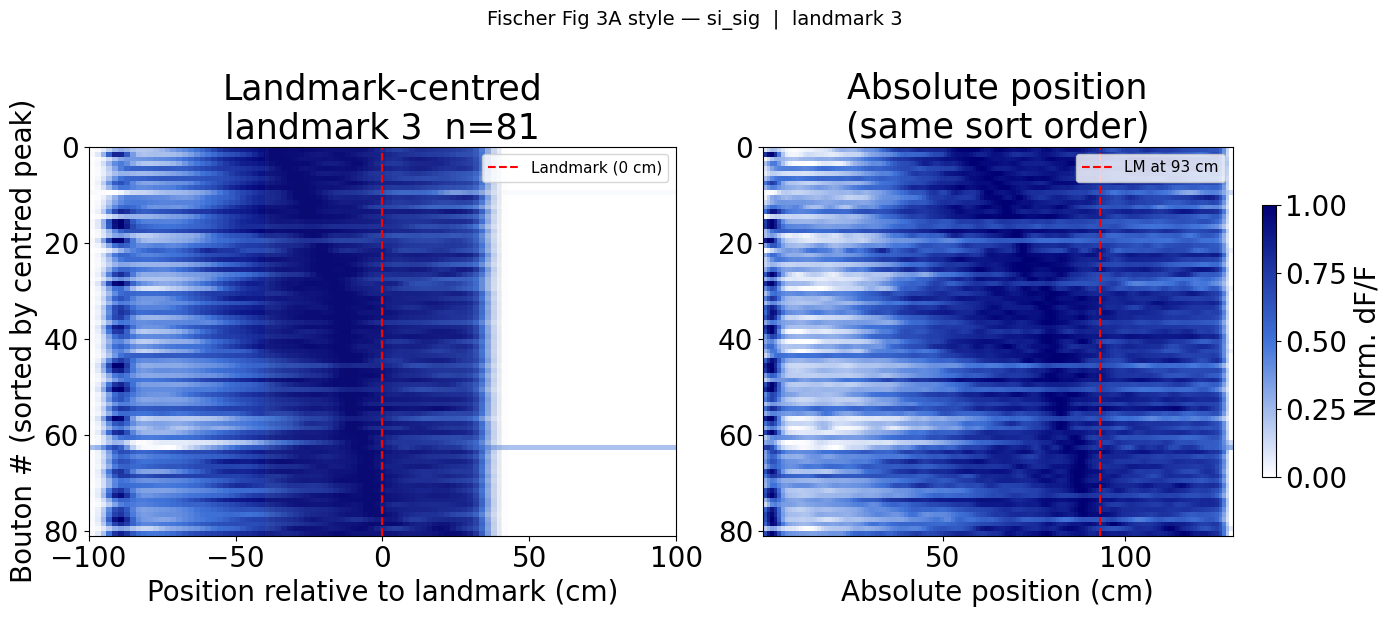


landmark_4  (61 boutons, lm_pos=120 cm)


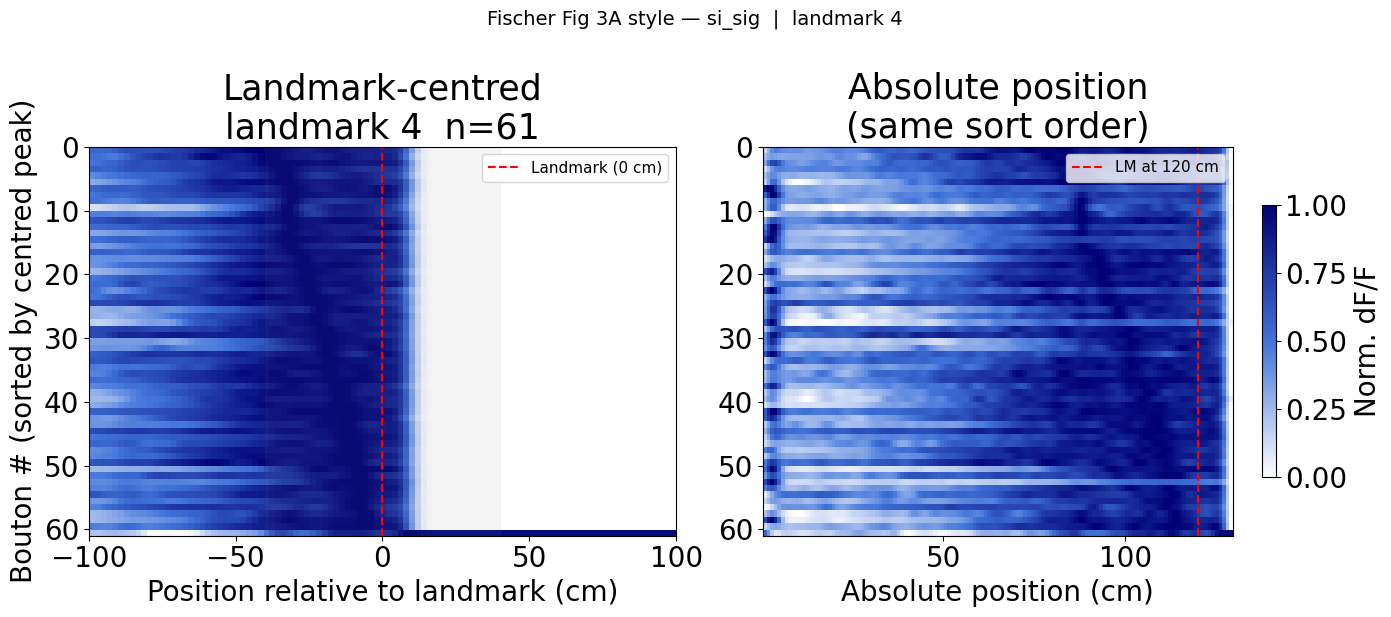


Population: si_sig_only

landmark_1  (15 boutons, lm_pos=37 cm)


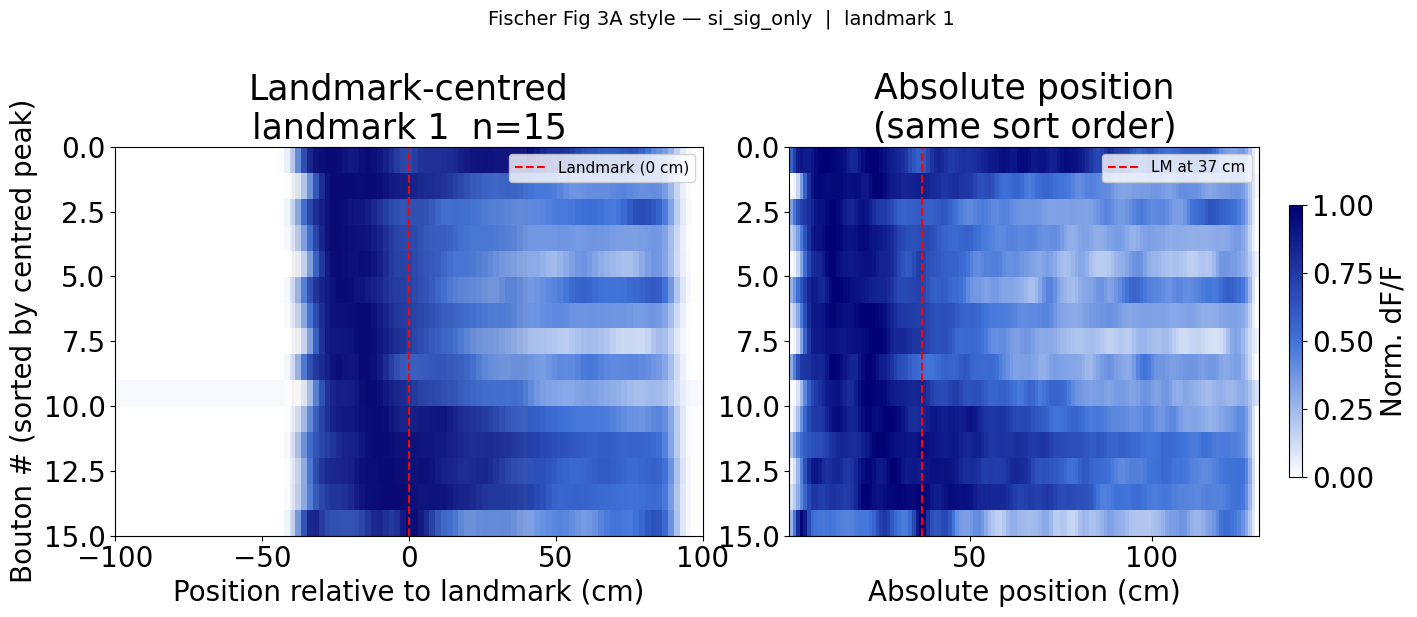


landmark_2  (35 boutons, lm_pos=65 cm)


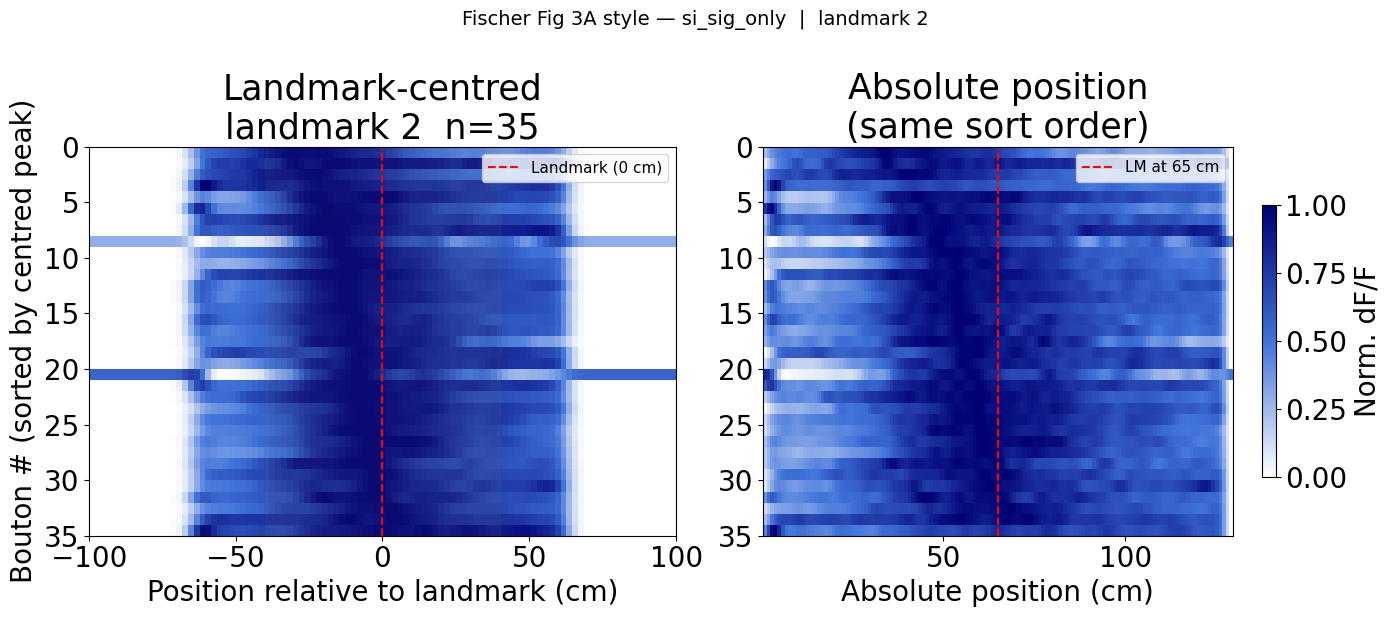


landmark_3  (63 boutons, lm_pos=93 cm)


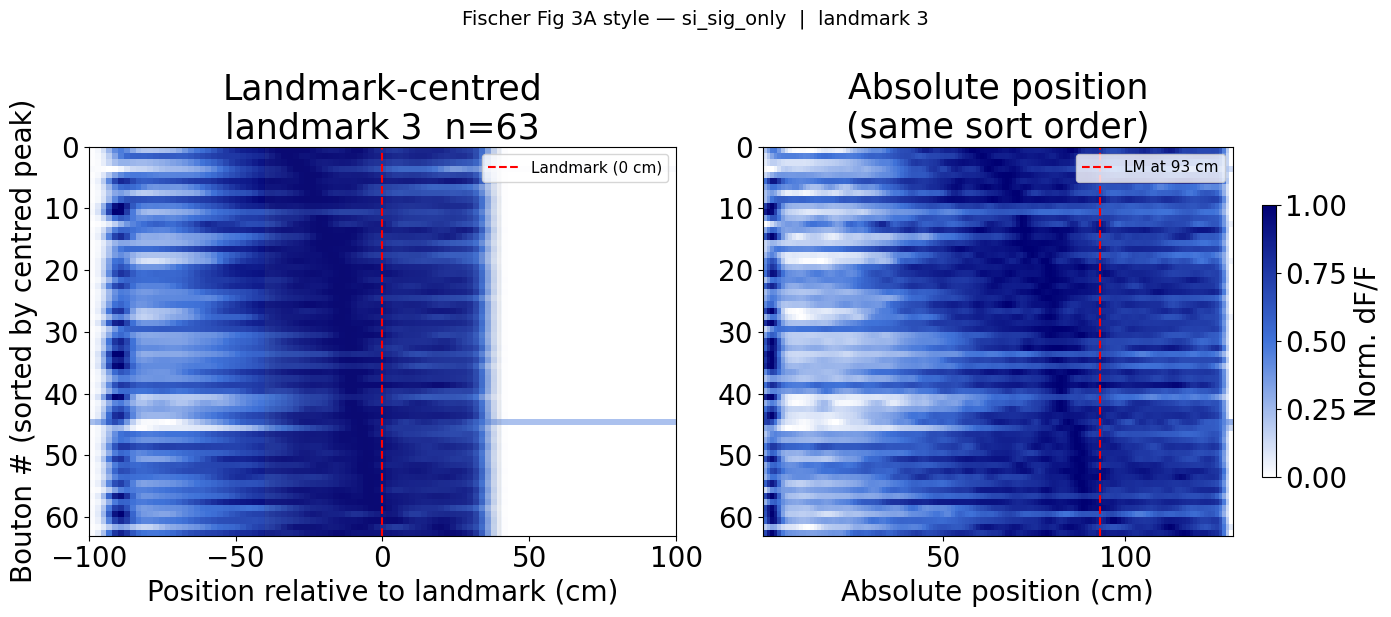


landmark_4  (57 boutons, lm_pos=120 cm)


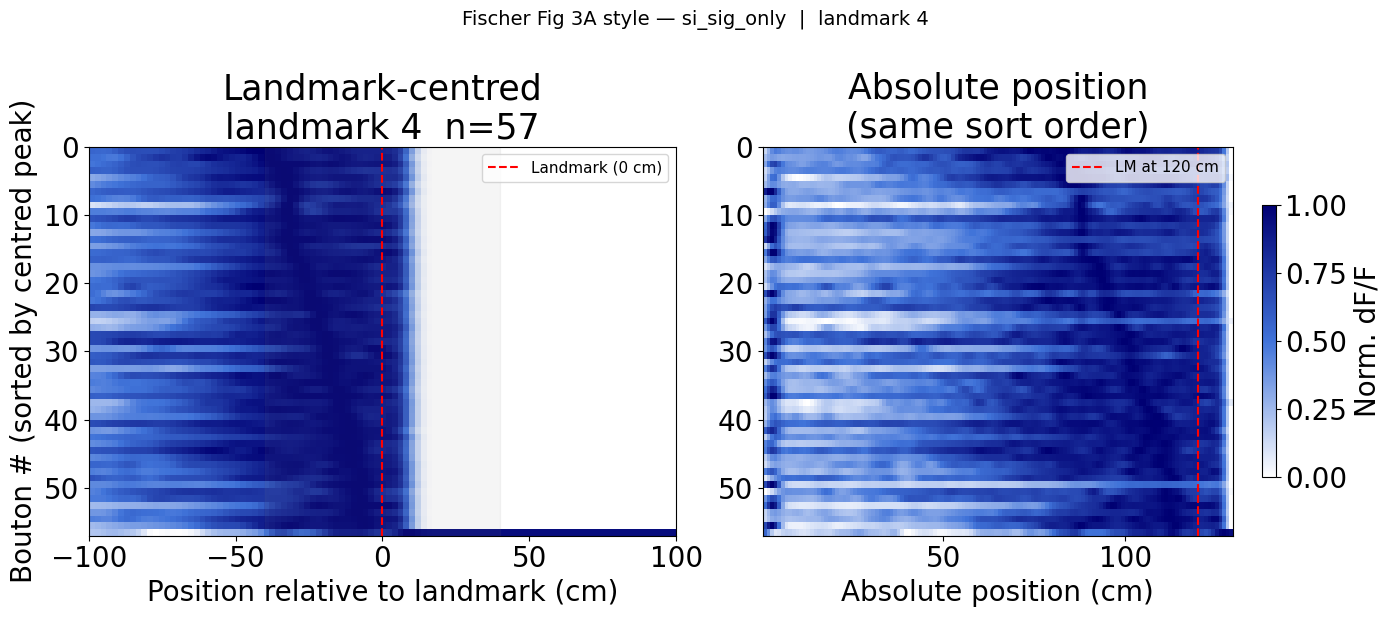

In [68]:
# ── Landmark positions (cm) — end of each approach window = landmark itself ───
LANDMARK_POS = {
    'landmark_1': 37,
    'landmark_2': 65,
    'landmark_3': 93,
    'landmark_4': 120,
}

# Centered bin grid: -100 to +100 cm, 2 cm steps  →  100 bins
CENTERED_BIN_EDGES   = np.arange(-101, 102, 2, dtype=float)
CENTERED_BIN_CENTERS = (CENTERED_BIN_EDGES[:-1] + CENTERED_BIN_EDGES[1:]) / 2

SORT_WINDOW_CM = 40.0   # sort boutons by peak within ±40 cm of landmark


# ── Helper: vectorised tuning in landmark-centred coordinates ─────────────────
def compute_centered_tuning_all(dFF_subset, location_cm, lm_pos_cm,
                                 centered_bin_edges, min_occ=2):
    """
    Vectorised tuning curves in landmark-centred coordinates.

    dFF_subset         : (n_boutons, n_frames)
    location_cm        : (n_frames,) absolute position
    lm_pos_cm          : float — landmark position; location shifted by -lm_pos_cm
    centered_bin_edges : (n_bins+1,)

    Returns
    -------
    tuning  : (n_boutons, n_bins)  NaN where occupancy < min_occ
    bin_ctr : (n_bins,)  centered bin centres
    """
    centered_loc = location_cm - lm_pos_cm
    n_bins  = len(centered_bin_edges) - 1
    bin_ctr = (centered_bin_edges[:-1] + centered_bin_edges[1:]) / 2
    n_frames = len(location_cm)

    raw_idx  = np.digitize(centered_loc, centered_bin_edges) - 1
    in_range = (raw_idx >= 0) & (raw_idx < n_bins)

    ind = np.zeros((n_frames, n_bins), dtype=np.float32)
    ind[np.arange(n_frames)[in_range], raw_idx[in_range]] = 1.0

    occupancy = ind.sum(axis=0)
    raw = dFF_subset.astype(np.float32) @ ind

    with np.errstate(invalid='ignore', divide='ignore'):
        tuning = np.where(occupancy >= min_occ,
                          raw.astype(np.float64) / occupancy,
                          np.nan)
    return tuning, bin_ctr


# ── Main plot function ────────────────────────────────────────────────────────
def plot_landmark_centered_heatmaps(anchor_name, lm_pos_cm,
                                     labels, engaged_mask, dFF,
                                     location_cm, bin_centers,
                                     centered_bin_edges,
                                     sort_window_cm=40.0,
                                     smooth_sigma=1.5,
                                     pop_name=''):
    """
    Two-panel heatmap for boutons classified to a single landmark anchor.
    Left  : dF/F in landmark-centred coordinates (landmark at 0, red dashed)
    Right : same boutons in absolute position (0-130 cm), same sort order
    """
    CMAP = LinearSegmentedColormap.from_list(
        'BlueBlack', [(1, 1, 1), (0.25, 0.45, 0.85), (0, 0, 0.45)])

    class_mask = (labels == anchor_name) & engaged_mask
    class_idx  = np.where(class_mask)[0]
    n_class    = len(class_idx)

    if n_class == 0:
        print(f"  No boutons classified to {anchor_name}, skipping.")
        return None

    print(f"\n{anchor_name}  ({n_class} boutons, lm_pos={lm_pos_cm} cm)")
    dFF_class = dFF[class_idx]   # (n_class, n_frames)

    # ── Centred tuning ────────────────────────────────────────────────────────
    tuning_ctr, ctr_bins = compute_centered_tuning_all(
        dFF_class, location_cm, lm_pos_cm, centered_bin_edges)

    # ── Absolute tuning ───────────────────────────────────────────────────────
    n_abs = len(bin_centers)
    half  = np.mean(np.diff(bin_centers)) / 2
    abs_edges = np.concatenate([[bin_centers[0] - half],
                                (bin_centers[:-1] + bin_centers[1:]) / 2,
                                [bin_centers[-1] + half]])
    abs_idx = np.clip(np.digitize(location_cm, abs_edges) - 1, 0, n_abs - 1)
    ind_abs = np.zeros((len(location_cm), n_abs), dtype=np.float32)
    ind_abs[np.arange(len(location_cm)), abs_idx] = 1.0
    occ_abs = ind_abs.sum(axis=0)
    raw_abs = dFF_class.astype(np.float32) @ ind_abs
    with np.errstate(invalid='ignore', divide='ignore'):
        tuning_abs = np.where(occ_abs >= 2,
                              raw_abs.astype(np.float64) / occ_abs, np.nan)

    # ── Smooth + normalise 0-1 per bouton ─────────────────────────────────────
    def _smooth_norm(mat, sigma):
        out = np.zeros_like(mat)
        for i in range(len(mat)):
            sm = gaussian_filter1d(np.nan_to_num(mat[i]), sigma=sigma)
            lo, hi = sm.min(), sm.max()
            out[i] = (sm - lo) / (hi - lo) if hi > lo else sm
        return out

    tc_ctr = _smooth_norm(tuning_ctr, smooth_sigma)
    tc_abs = _smooth_norm(tuning_abs, smooth_sigma)

    # ── Sort by peak within ±sort_window_cm in centred space ──────────────────
    in_sort = np.where(np.abs(ctr_bins) <= sort_window_cm)[0]
    if len(in_sort) == 0:
        in_sort = np.arange(len(ctr_bins))

    peak_pos = ctr_bins[in_sort[np.nanargmax(tc_ctr[:, in_sort], axis=1)]]
    sort_order = np.argsort(peak_pos)

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.imshow(tc_ctr[sort_order], aspect='auto', cmap=CMAP, vmin=0, vmax=1,
              extent=[ctr_bins[0], ctr_bins[-1], n_class, 0])
    ax.axvline(0, color='red', lw=1.5, ls='--', label='Landmark (0 cm)')
    ax.axvspan(-sort_window_cm, sort_window_cm, color='gray', alpha=0.08, zorder=0)
    ax.set_xlabel('Position relative to landmark (cm)')
    ax.set_ylabel('Bouton # (sorted by centred peak)')
    ax.set_title(f'Landmark-centred\n{anchor_name.replace("_", " ")}  n={n_class}')
    ax.legend(fontsize=11, loc='upper right')

    ax = axes[1]
    im = ax.imshow(tc_abs[sort_order], aspect='auto', cmap=CMAP, vmin=0, vmax=1,
                   extent=[bin_centers[0], bin_centers[-1], n_class, 0])
    ax.axvline(lm_pos_cm, color='red', lw=1.5, ls='--', label=f'LM at {lm_pos_cm} cm')
    ax.set_xlabel('Absolute position (cm)')
    ax.set_title(f'Absolute position\n(same sort order)')
    ax.legend(fontsize=11, loc='upper right')

    plt.colorbar(im, ax=axes[1], label='Norm. dF/F', shrink=0.7)
    fig.suptitle(
        f'Fischer Fig 3A style — {pop_name}  |  {anchor_name.replace("_", " ")}',
        fontsize=14, y=1.02)
    plt.tight_layout()
    return fig


# ── Run for both populations, all 4 landmarks ────────────────────────────────
for pop_name, labels, engaged in [
    ('si_sig',      labels_sisig,  engaged_sisig),
    ('si_sig_only', labels_sionly, engaged_sionly),
]:
    print(f"\n{'='*60}")
    print(f"Population: {pop_name}")
    print(f"{'='*60}")
    for anchor_name, lm_pos in LANDMARK_POS.items():
        fig = plot_landmark_centered_heatmaps(
            anchor_name, lm_pos,
            labels, engaged, data['dFF'],
            data['location_cm'], data['bin_centers'],
            CENTERED_BIN_EDGES,
            sort_window_cm=SORT_WINDOW_CM,
            smooth_sigma=1.5,
            pop_name=pop_name,
        )
        if fig is not None:
            plt.show()
